In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Data and Get an Overview

In [4]:

# Set plot style
sns.set(style="whitegrid")

# Load the dataset
# We point to the raw data file we placed in the data/raw folder
try:
    df = pd.read_csv('../data/raw/data.csv')
except FileNotFoundError:
    print("Error: 'transactions.csv' not found. Please download it from Kaggle and place it in the 'data/raw/' directory.")

# Display the first 5 rows to get a feel for the data
print("First 5 rows of the dataset:")
print(df.head())

# Get a concise summary of the dataframe
print("\nDataset Info:")
df.info()

# Get the shape of the dataset (rows, columns)
print(f"\nDataset shape: {df.shape}")

First 5 rows of the dataset:
         TransactionId         BatchId       AccountId       SubscriptionId  \
0  TransactionId_76871   BatchId_36123  AccountId_3957   SubscriptionId_887   
1  TransactionId_73770   BatchId_15642  AccountId_4841  SubscriptionId_3829   
2  TransactionId_26203   BatchId_53941  AccountId_4229   SubscriptionId_222   
3    TransactionId_380  BatchId_102363   AccountId_648  SubscriptionId_2185   
4  TransactionId_28195   BatchId_38780  AccountId_4841  SubscriptionId_3829   

        CustomerId CurrencyCode  CountryCode    ProviderId     ProductId  \
0  CustomerId_4406          UGX          256  ProviderId_6  ProductId_10   
1  CustomerId_4406          UGX          256  ProviderId_4   ProductId_6   
2  CustomerId_4683          UGX          256  ProviderId_6   ProductId_1   
3   CustomerId_988          UGX          256  ProviderId_1  ProductId_21   
4   CustomerId_988          UGX          256  ProviderId_4   ProductId_6   

      ProductCategory    ChannelId   Am

### 2. Summary Statistics

In [5]:
# Get descriptive statistics for numerical columns
print("Summary statistics for numerical features:")
print(df.describe())

Summary statistics for numerical features:
       CountryCode        Amount         Value  PricingStrategy   FraudResult
count      95662.0  9.566200e+04  9.566200e+04     95662.000000  95662.000000
mean         256.0  6.717846e+03  9.900584e+03         2.255974      0.002018
std            0.0  1.233068e+05  1.231221e+05         0.732924      0.044872
min          256.0 -1.000000e+06  2.000000e+00         0.000000      0.000000
25%          256.0 -5.000000e+01  2.750000e+02         2.000000      0.000000
50%          256.0  1.000000e+03  1.000000e+03         2.000000      0.000000
75%          256.0  2.800000e+03  5.000000e+03         2.000000      0.000000
max          256.0  9.880000e+06  9.880000e+06         4.000000      1.000000


### 3. Distribution of Numerical and Categorical Features

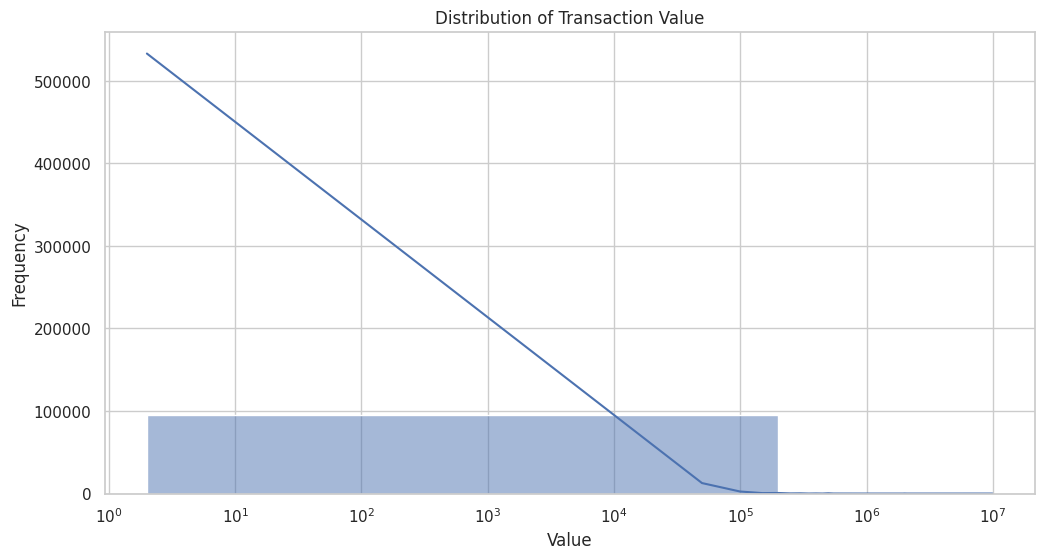

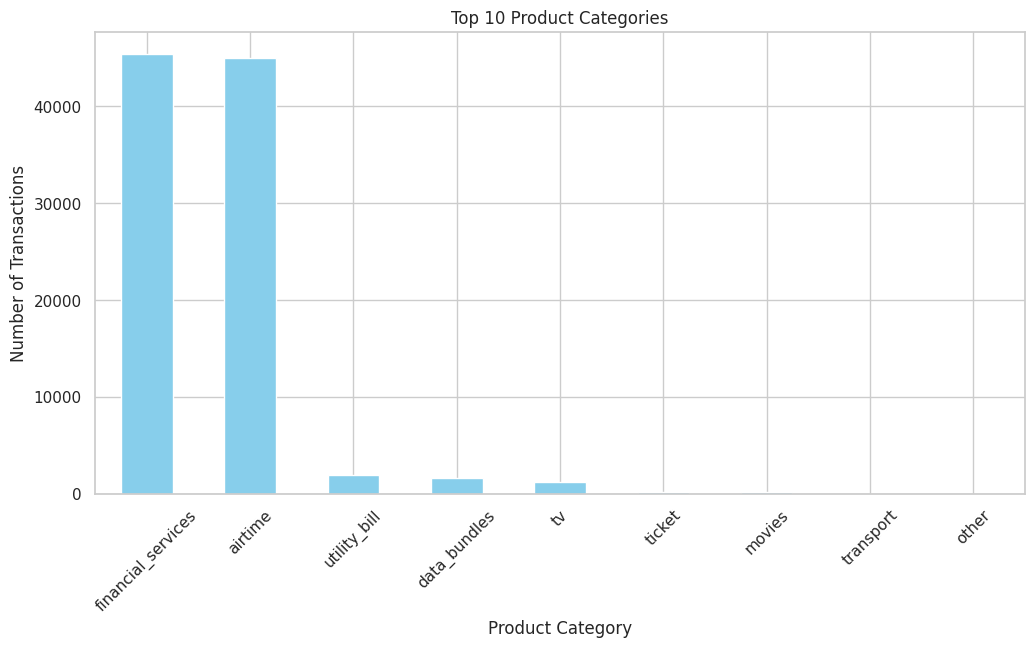

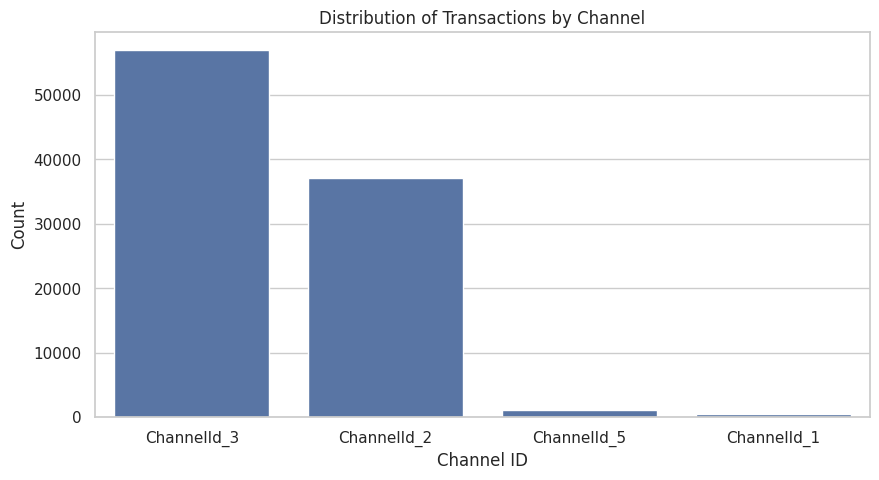

In [6]:
# Visualize the distribution of the 'Value' column
plt.figure(figsize=(12, 6))
sns.histplot(df['Value'], bins=50, kde=True)
plt.title('Distribution of Transaction Value')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.xscale('log') # Use a log scale because the data is highly skewed
plt.show()

# Visualize the top 10 product categories
plt.figure(figsize=(12, 6))
df['ProductCategory'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

# Visualize the distribution of ChannelId
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='ChannelId', order=df['ChannelId'].value_counts().index)
plt.title('Distribution of Transactions by Channel')
plt.xlabel('Channel ID')
plt.ylabel('Count')
plt.show()

### 4. Missing Values and Outliers

Missing values per column:
TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64


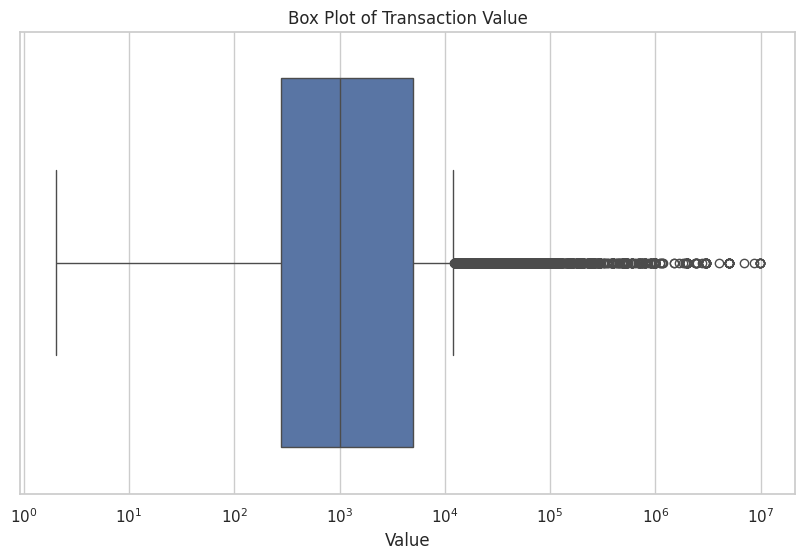

In [7]:
# Identify missing values
print("Missing values per column:")
print(df.isnull().sum())

# Use a box plot to identify outliers in 'Value'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Value'])
plt.title('Box Plot of Transaction Value')
plt.xscale('log') # Use a log scale to better visualize the distribution
plt.show()